In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

In [4]:
# 1. Load dataset
df = pd.read_csv(r"C:\Users\mymac\Downloads\Retail_Sales - retail_sales_data.csv")
df

,TransactionID,Date,StoreID,ProductID,Category,UnitPrice,UnitsSold,Revenue,DiscountApplied,HolidayFlag
0,1,2022-03-20,43,3012,Groceries,145.62,40,5824.80,10,1
1,2,2022-07-12,50,5010,Sports,124.19,13,1614.47,10,0
2,3,2020-03-05,10,1019,Electronics,210.82,39,8221.98,10,0
3,4,2020-11-02,2,2019,Clothing,96.05,10,960.50,20,1
4,5,2019-12-20,15,5010,Sports,274.84,11,3023.24,20,1
...,...,...,...,...,...,...,...,...,...,...
69995,69996,2018-03-28,30,4014,Home & Kitchen,221.18,24,5308.32,5,1
69996,69997,2021-01-06,44,3033,Groceries,192.67,20,3853.40,20,1
69997,69998,2022-05-13,25,3049,Groceries,113.46,24,2723.04,20,0
69998,69999,2022-09-20,23,1001,Electronics,57.93,4,231.72,10,1


In [5]:
# 2. Prepare data
df['Date'] = pd.to_datetime(df['Date'])

In [6]:
# 3. Aggregate revenue by date
daily_sales = df.groupby('Date', as_index=False)['Revenue'].sum()


In [7]:
# 4. Rename columns for Prophet
daily_sales = daily_sales.rename(columns={'Date': 'ds', 'Revenue': 'y'})


In [8]:
# 5. Build and train model
model = Prophet()
model.fit(daily_sales)

13:10:53 - cmdstanpy - INFO - Chain [1] start processing
13:10:54 - cmdstanpy - INFO - Chain [1] done processing


In [9]:
# 6. Forecast next 30 days
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

In [13]:
# 7. Save output for Power BI
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('forecast_output.csv', index=False)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('forecast_output.csv', index=False)

print("Forecast file 'forecast_output.csv' has been created and saved in your current folder.")


Forecast file 'forecast_output.csv' has been created and saved in your current folder.


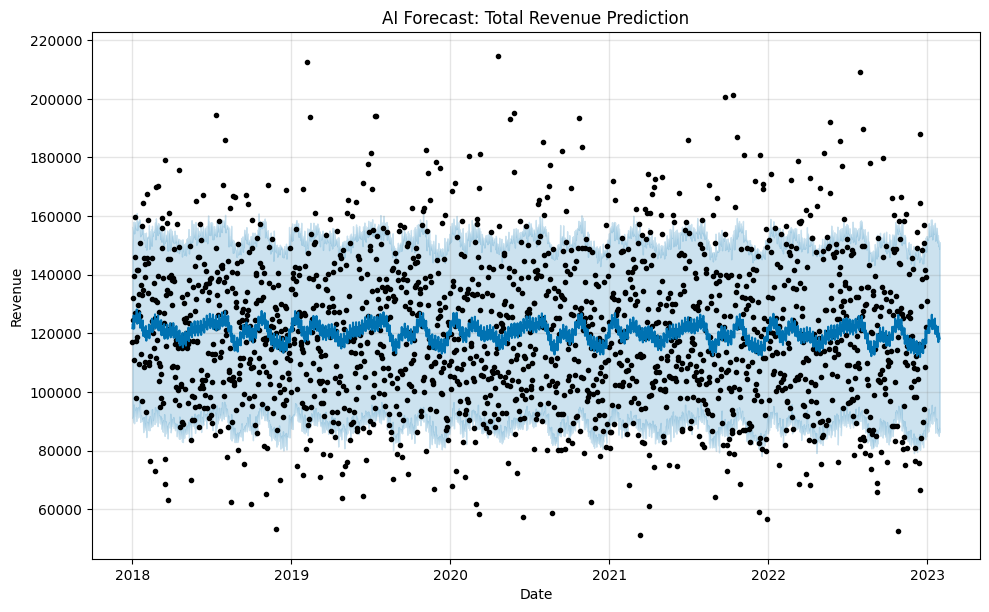

In [11]:
# 8. Plot forecast
model.plot(forecast)
plt.title("AI Forecast: Total Revenue Prediction")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

In [14]:
import os
os.getcwd()

'C:\\Users\\mymac'

In [15]:
'C:\\Users\\mymac\\Downloads'

'C:\\Users\\mymac\\Downloads'

In [18]:
import os
os.getcwd()

'C:\\Users\\mymac'

In [17]:
pd.read_csv('forecast_output.csv').head()

,ds,yhat,yhat_lower,yhat_upper
0,2018-01-01,121738.633865,91162.699542,150348.408935
1,2018-01-02,123239.504031,91523.107965,156432.454617
2,2018-01-03,121620.851331,89630.354849,154593.672733
3,2018-01-04,126093.886547,95704.905230,158134.207506
4,2018-01-05,121638.392406,89276.059957,154055.787433
